# Alzheimer's Disease Classification
## Data Science Project

## Alzheimer’s Disease Classification
This project analyzes patient information related to:

Demographics

Lifestyle

Medical history

Clinical measurements

Cognitive assessments

Functional assessments

Symptoms

to understand their association with Alzheimer's Disease and eventually build a classification model that predicts the diagnosis outcome.

## BUSINESS OBJECTIVE

## Objective 1 — Detect patterns and early indicators

We want to identify patterns in patient data that may be associated with Alzheimer's onset.

## Objective 2 — Identify key risk factors

We need to investigate factors such as:

Family history,
Diabetes,
Cardiovascular disease,
Depression,
Hypertension,
Head injury,
Lifestyle,
Cognitive measures,
Functional measures,
Symptoms

The objective is to identify which factors are associated with different diagnosis patterns.

The source document explicitly states that identifying key risk factors contributing to disease progression is one of the project goals.

## Objective 3 — Develop classification models

Eventually, we'll build machine learning models that predict:

Diagnosis = 0

or

Diagnosis = 1

The business document explicitly identifies Diagnosis as the target variable.

## Objective 4 — Support healthcare decisions

The project aims to support clinicians and researchers with data-driven insights, potentially helping with early detection, patient management, and healthcare research.

## BUSINESS PROBLEM - STATEMENT

Healthcare organizations have access to demographic, lifestyle, medical, cognitive, functional, and symptom-related patient information, but it can be difficult to identify meaningful patterns associated with Alzheimer's Disease. The objective of this project is to analyze these factors, identify important associations with Alzheimer's diagnosis, and eventually develop a machine learning classification system that can classify patients based on their diagnosis outcome.

## MACHINE LEARNING OBJECTIVE

The ML problem is:

## Problem Type

Supervised Machine Learning

# because we already have a known target: Diagnosis

## Learning Type

Classification

## Specifically

Binary Classification

because:

0 → No Alzheimer's Disease
1 → Alzheimer's Disease

The official dataset description confirms that Diagnosis is the target variable and uses 0/1 coding.

# IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET

In [2]:
df = pd.read_csv("alzheimers_disease_data.csv")

In [3]:
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


# PART - 1

# EDA - EXPLORATORY DATA ANALYSIS

In [4]:
df.shape

(2149, 35)

In [5]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [7]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique().sort_values()

DoctorInCharge                  1
Diagnosis                       2
Hypertension                    2
HeadInjury                      2
Depression                      2
Diabetes                        2
CardiovascularDisease           2
FamilyHistoryAlzheimers         2
BehavioralProblems              2
Confusion                       2
PersonalityChanges              2
DifficultyCompletingTasks       2
Smoking                         2
Forgetfulness                   2
Gender                          2
Disorientation                  2
MemoryComplaints                2
EducationLevel                  4
Ethnicity                       4
Age                            31
DiastolicBP                    60
SystolicBP                     90
CholesterolTriglycerides     2149
MMSE                         2149
FunctionalAssessment         2149
CholesterolLDL               2149
CholesterolTotal             2149
ADL                          2149
SleepQuality                 2149
DietQuality   

In [11]:
df_model = df.drop(columns=["PatientID", "DoctorInCharge"])

In [12]:
df_model.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


# Target Variable Analysis

In [13]:
df["Diagnosis"].value_counts()

Diagnosis
0    1389
1     760
Name: count, dtype: int64

# TARGET PLOT

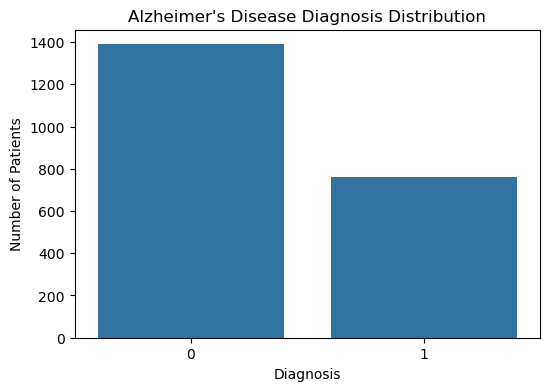

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="Diagnosis", data=df)

plt.title("Alzheimer's Disease Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.show()

# Continuous Variable Analysis

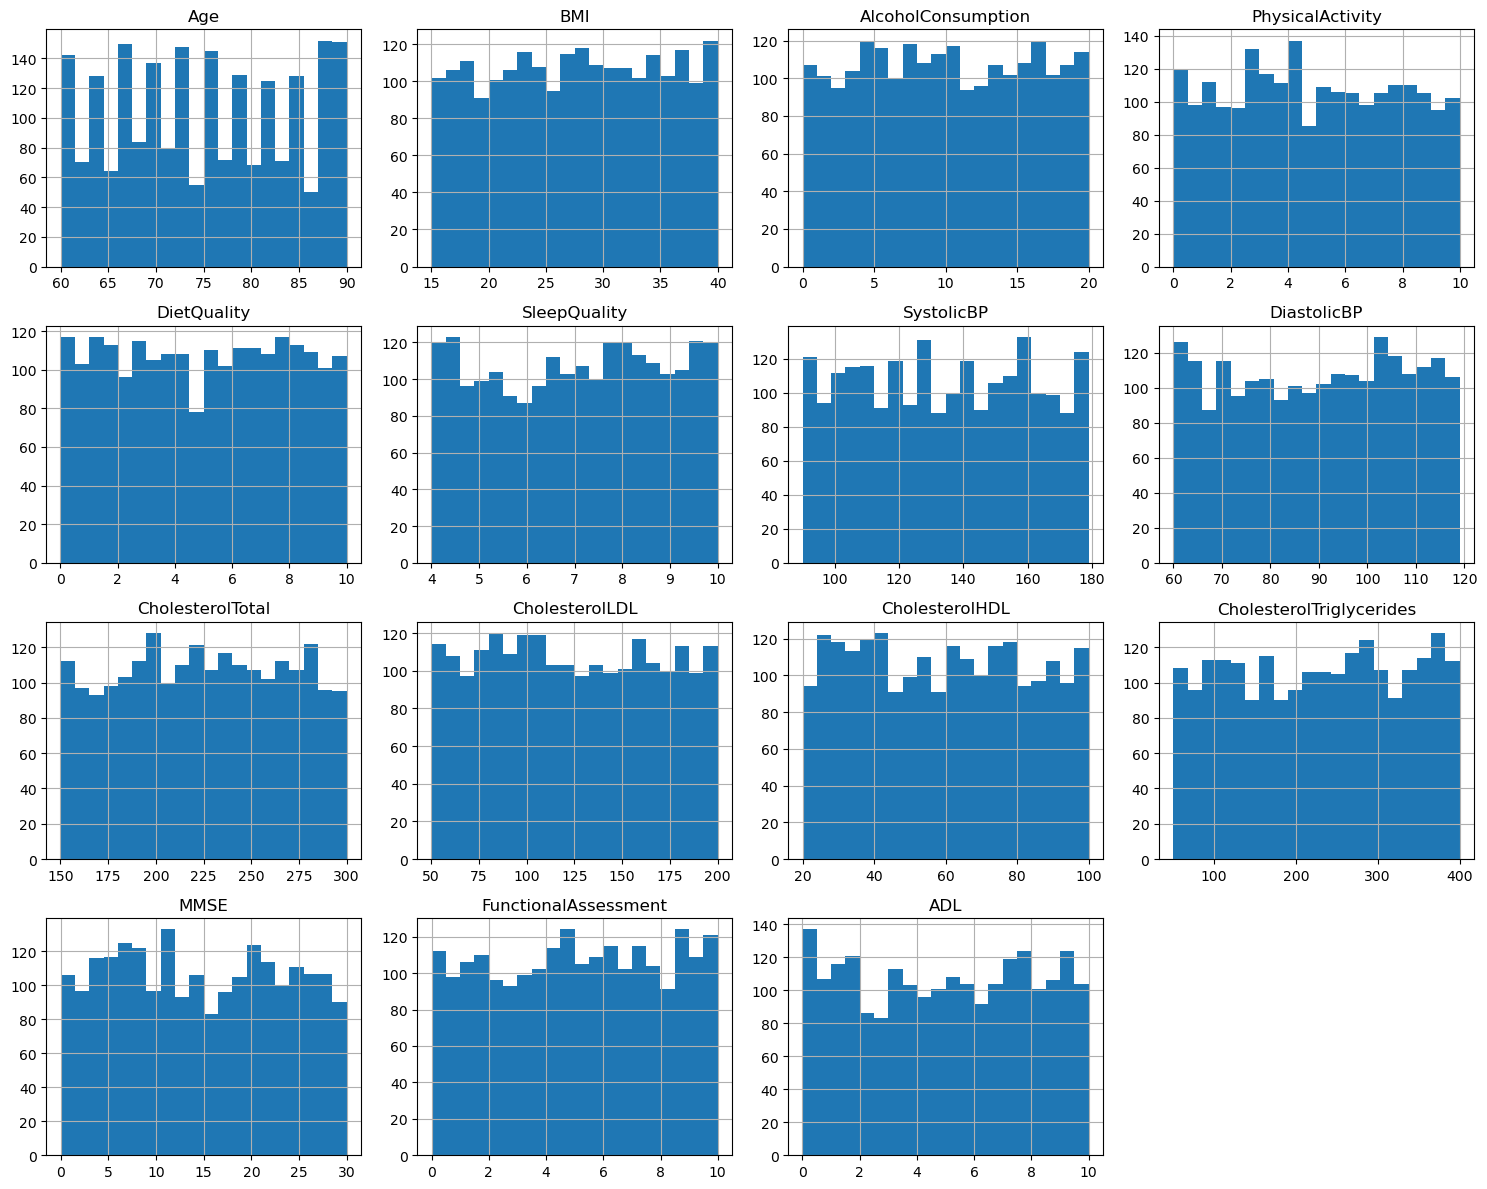

In [15]:
numeric_cols = [
    "Age", "BMI", "AlcoholConsumption",
    "PhysicalActivity", "DietQuality",
    "SleepQuality", "SystolicBP",
    "DiastolicBP", "CholesterolTotal",
    "CholesterolLDL", "CholesterolHDL",
    "CholesterolTriglycerides", "MMSE",
    "FunctionalAssessment", "ADL"
]

df[numeric_cols].hist(figsize=(15,12), bins=20)

plt.tight_layout()
plt.show()

# Outlier Detection

In [16]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(col, ":", outliers)

Age : 0
BMI : 0
AlcoholConsumption : 0
PhysicalActivity : 0
DietQuality : 0
SleepQuality : 0
SystolicBP : 0
DiastolicBP : 0
CholesterolTotal : 0
CholesterolLDL : 0
CholesterolHDL : 0
CholesterolTriglycerides : 0
MMSE : 0
FunctionalAssessment : 0
ADL : 0


# Boxplot Analysis

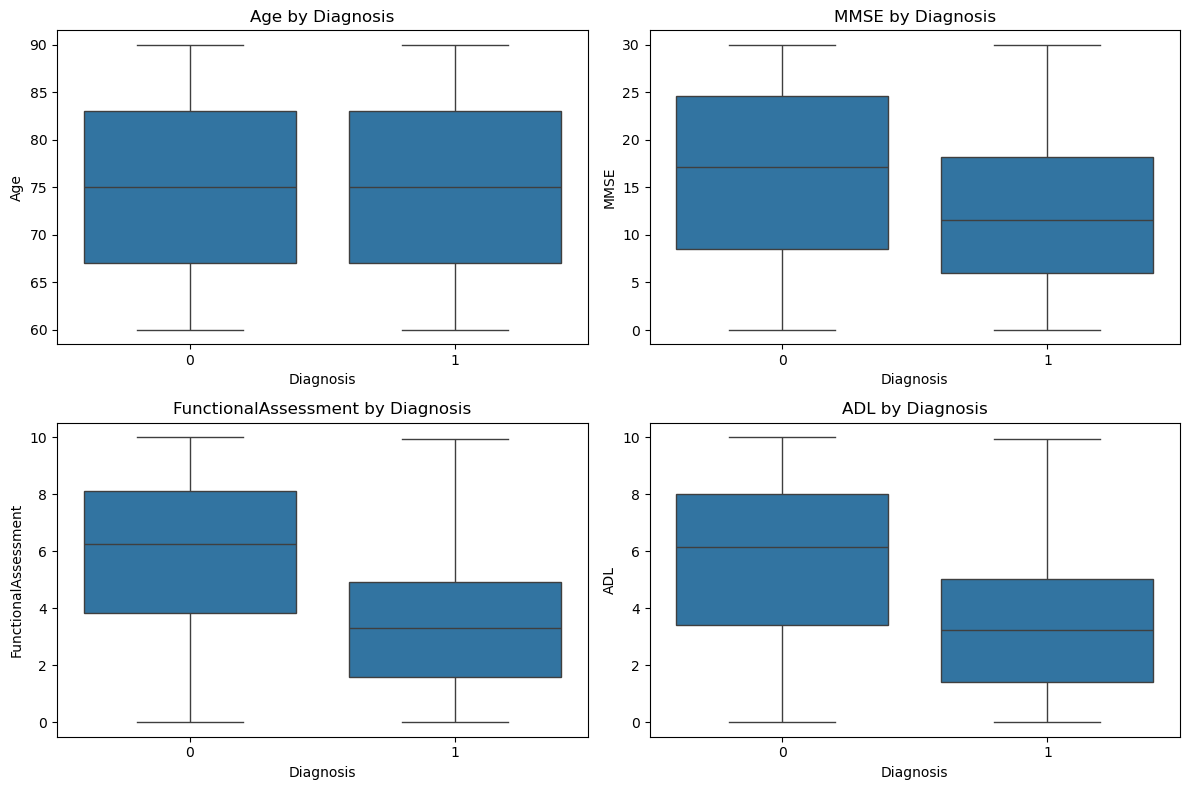

In [17]:
important_cols = [
    "Age",
    "MMSE",
    "FunctionalAssessment",
    "ADL"
]

plt.figure(figsize=(12,8))

for i, col in enumerate(important_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(x="Diagnosis", y=col, data=df)
    plt.title(f"{col} by Diagnosis")

plt.tight_layout()
plt.show()

# Correlation Analysis

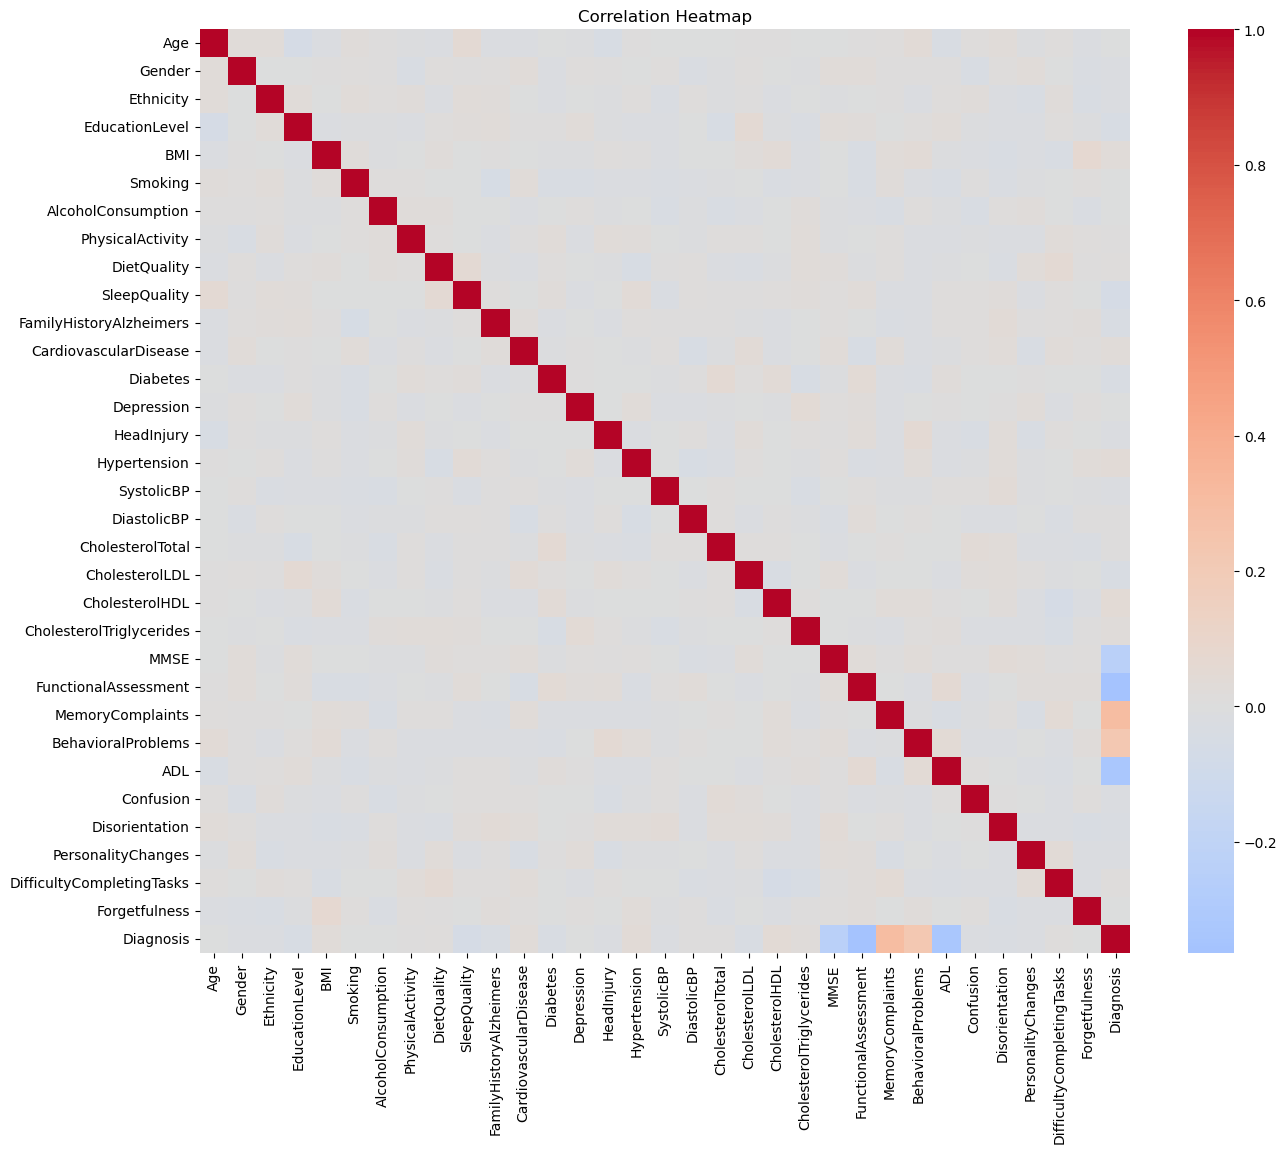

In [18]:
corr = df_model.corr(numeric_only=True)

plt.figure(figsize=(15,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# EDA — Target-Focused Analysis

# Diagnosis vs Important Categorical Features

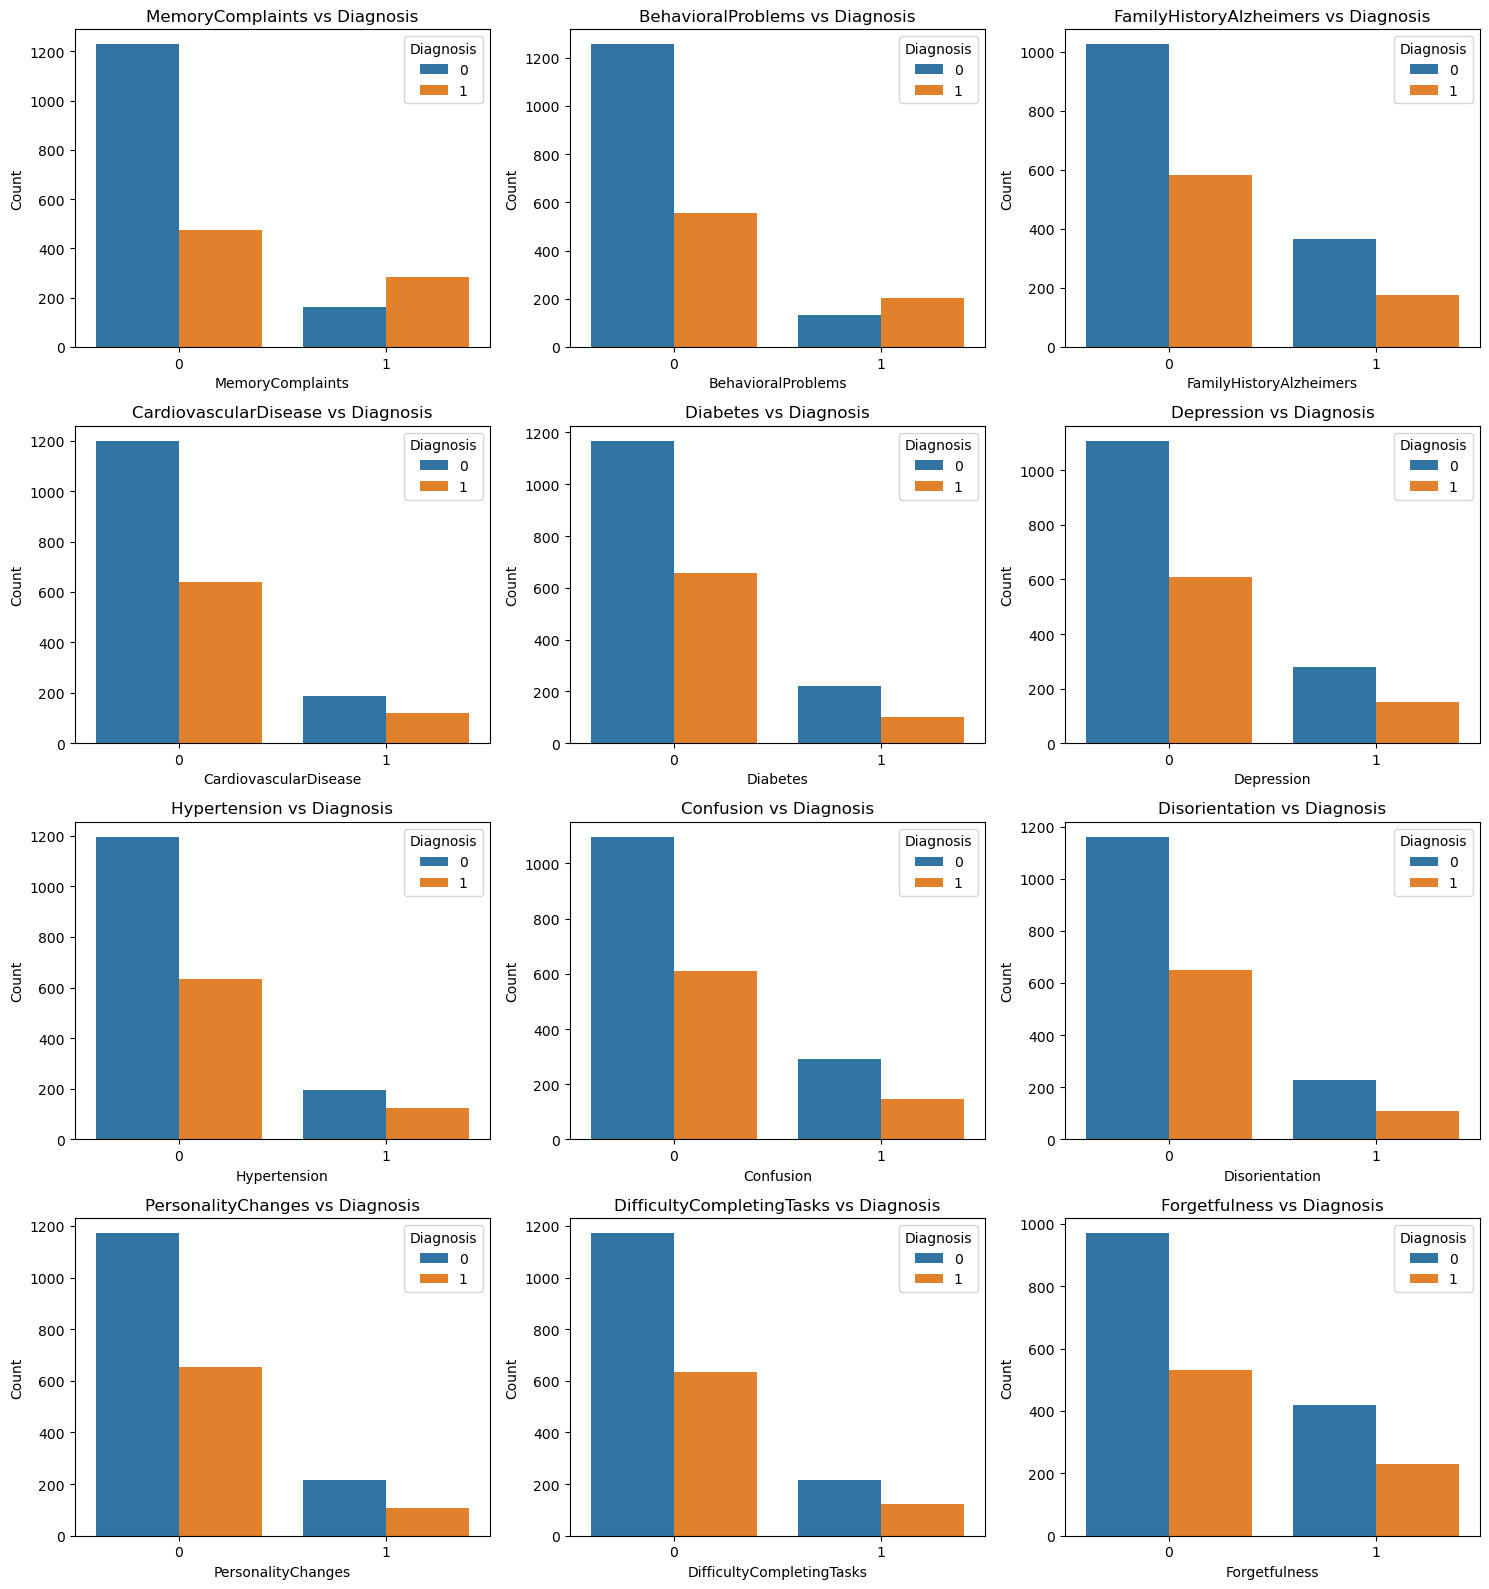

In [19]:
categorical_features = [
    "MemoryComplaints",
    "BehavioralProblems",
    "FamilyHistoryAlzheimers",
    "CardiovascularDisease",
    "Diabetes",
    "Depression",
    "Hypertension",
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness"
]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for ax, col in zip(axes.flat, categorical_features):
    sns.countplot(
        data=df,
        x=col,
        hue="Diagnosis",
        ax=ax
    )
    ax.set_title(f"{col} vs Diagnosis")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Diagnosis Rate by Important Binary Features

In [20]:
for col in categorical_features:
    print("\n", col)
    print(df.groupby(col)["Diagnosis"].mean().round(3))


 MemoryComplaints
MemoryComplaints
0    0.278
1    0.640
Name: Diagnosis, dtype: float64

 BehavioralProblems
BehavioralProblems
0    0.307
1    0.602
Name: Diagnosis, dtype: float64

 FamilyHistoryAlzheimers
FamilyHistoryAlzheimers
0    0.363
1    0.327
Name: Diagnosis, dtype: float64

 CardiovascularDisease
CardiovascularDisease
0    0.347
1    0.390
Name: Diagnosis, dtype: float64

 Diabetes
Diabetes
0    0.360
1    0.318
Name: Diagnosis, dtype: float64

 Depression
Depression
0    0.355
1    0.348
Name: Diagnosis, dtype: float64

 Hypertension
Hypertension
0    0.347
1    0.394
Name: Diagnosis, dtype: float64

 Confusion
Confusion
0    0.358
1    0.336
Name: Diagnosis, dtype: float64

 Disorientation
Disorientation
0    0.359
1    0.326
Name: Diagnosis, dtype: float64

 PersonalityChanges
PersonalityChanges
0    0.358
1    0.330
Name: Diagnosis, dtype: float64

 DifficultyCompletingTasks
DifficultyCompletingTasks
0    0.352
1    0.364
Name: Diagnosis, dtype: float64

 Forgetfulnes

# Continuous Features vs Diagnosis

# Compare Numerical Features by Diagnosis

In [21]:
continuous_features = [
    "Age",
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "SleepQuality",
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides",
    "MMSE",
    "FunctionalAssessment",
    "ADL"
]

df.groupby("Diagnosis")[continuous_features].mean().T

Diagnosis,0,1
Age,74.945284,74.842105
BMI,27.515092,27.912670
AlcoholConsumption,10.071880,9.980156
PhysicalActivity,4.907640,4.943160
DietQuality,4.974839,5.026581
SleepQuality,7.124832,6.916292
SystolicBP,134.564435,133.717105
DiastolicBP,89.778978,89.973684
CholesterolTotal,224.996342,225.565197
CholesterolLDL,125.361434,122.461726


# Boxplots of Key Features

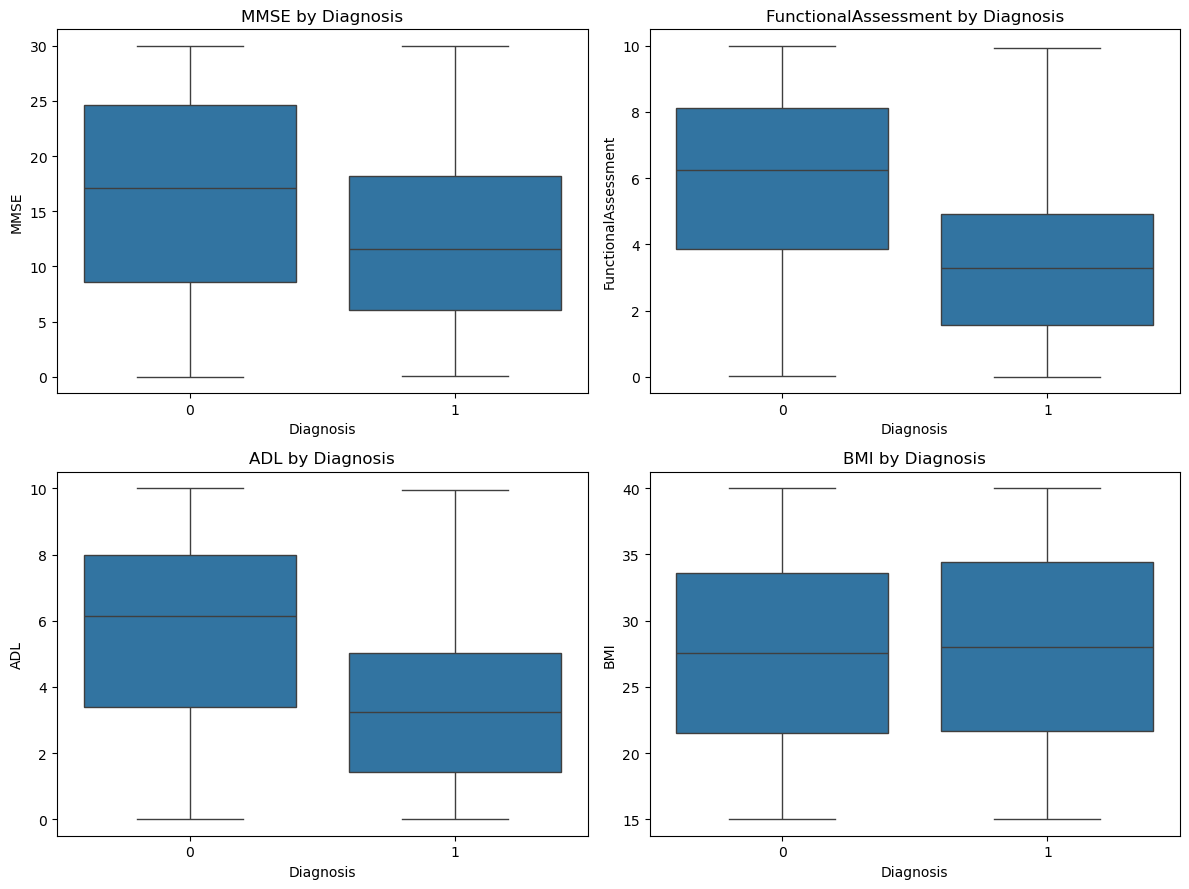

In [22]:
key_features = [
    "MMSE",
    "FunctionalAssessment",
    "ADL",
    "BMI"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, col in zip(axes.flat, key_features):
    sns.boxplot(
        data=df,
        x="Diagnosis",
        y=col,
        ax=ax
    )
    ax.set_title(f"{col} by Diagnosis")

plt.tight_layout()
plt.show()

# Top Correlations with Diagnosis

In [23]:
target_corr = (
    df.drop(columns=["DoctorInCharge"])
      .corr(numeric_only=True)["Diagnosis"]
      .drop("Diagnosis")
      .sort_values(key=abs, ascending=False)
)

target_corr.head(10)

FunctionalAssessment   -0.364898
ADL                    -0.332346
MemoryComplaints        0.306742
MMSE                   -0.237126
BehavioralProblems      0.224350
SleepQuality           -0.056548
EducationLevel         -0.043966
CholesterolHDL          0.042584
PatientID               0.041019
Hypertension            0.035080
Name: Diagnosis, dtype: float64

# Visualize Top Correlations

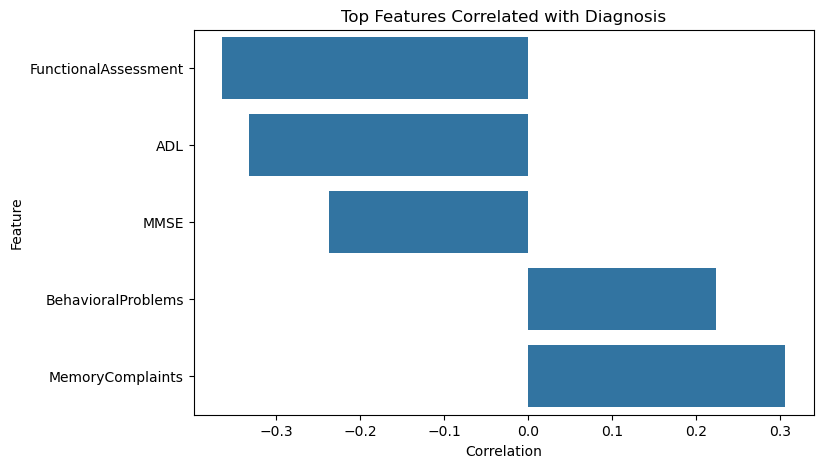

In [24]:
top_corr = target_corr.head(5).sort_values()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with Diagnosis")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

# Age Distribution by Diagnosis

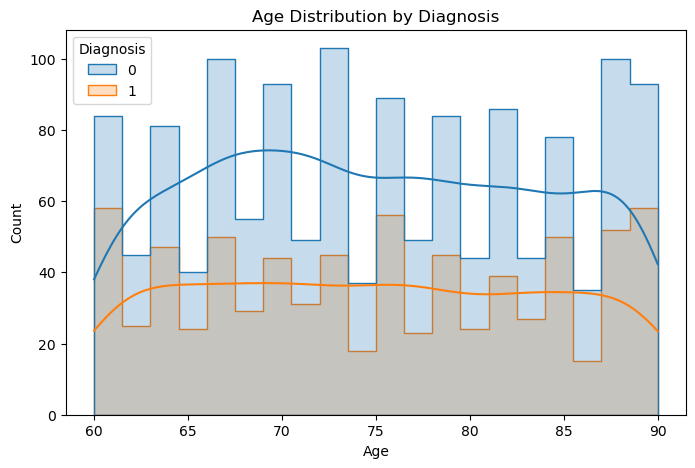

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Diagnosis",
    kde=True,
    bins=20,
    element="step"
)

plt.title("Age Distribution by Diagnosis")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

# Diagnosis vs Gender

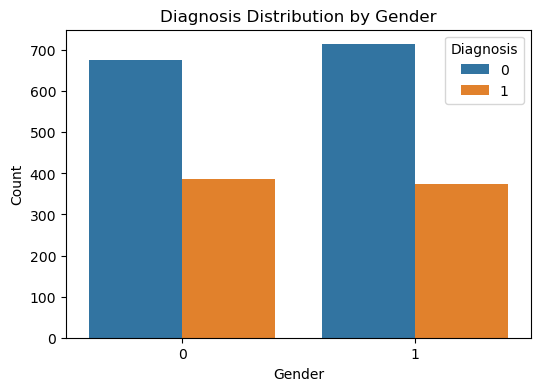

In [26]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Diagnosis"
)

plt.title("Diagnosis Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

# Diagnosis vs Lifestyle Factors

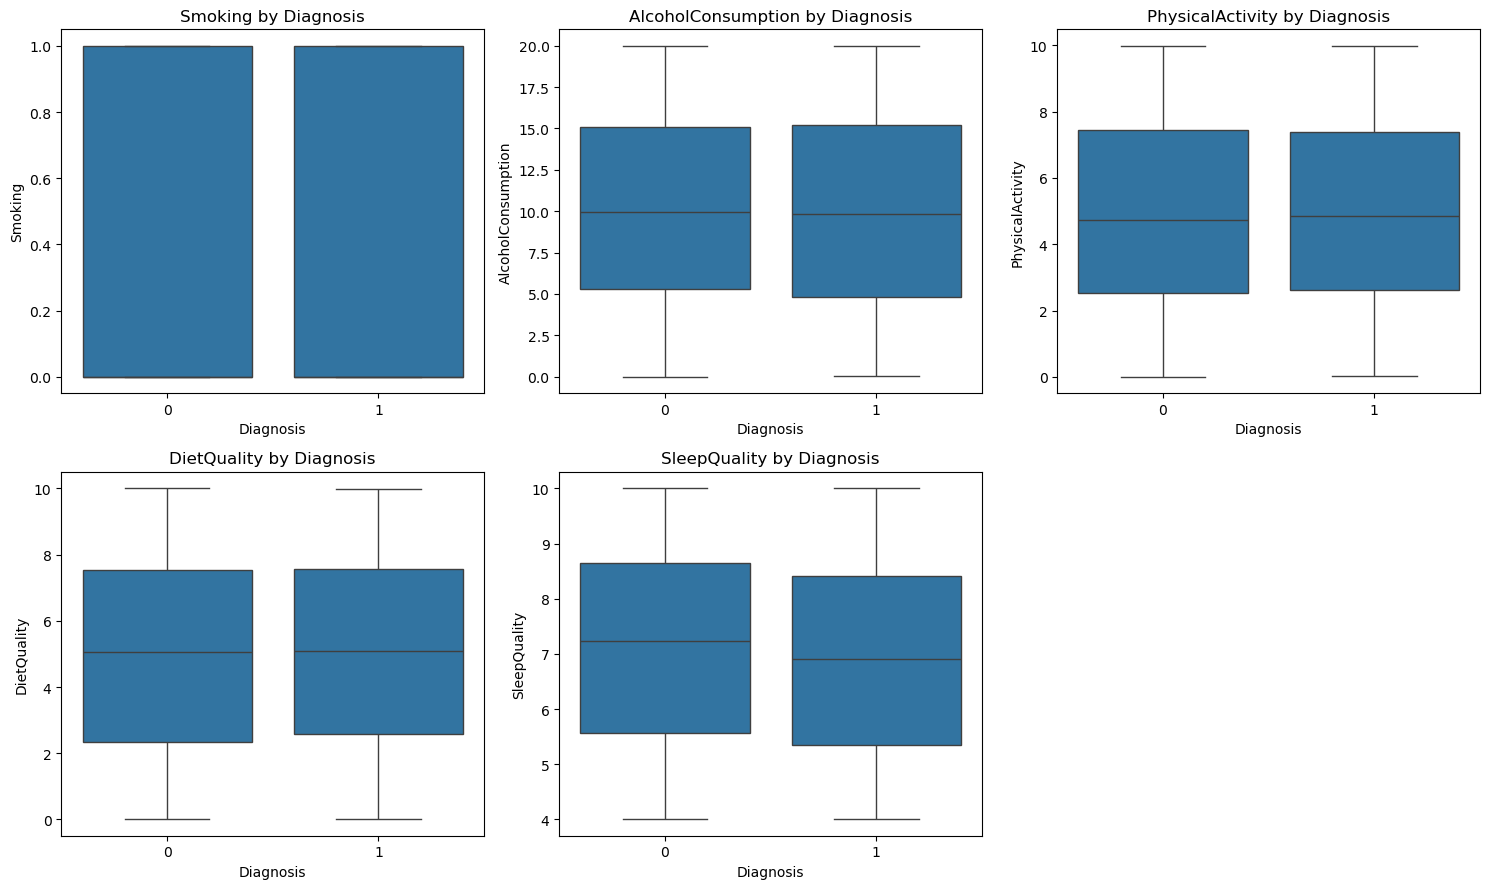

In [27]:
lifestyle_features = [
    "Smoking",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "SleepQuality"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, col in zip(axes.flat, lifestyle_features):
    if df[col].nunique() <= 5:
        sns.boxplot(data=df, x="Diagnosis", y=col, ax=ax)
    else:
        sns.boxplot(data=df, x="Diagnosis", y=col, ax=ax)
    
    ax.set_title(f"{col} by Diagnosis")

axes.flat[-1].axis("off")

plt.tight_layout()
plt.show()

# EDA FINDINGS


# EDA CONCLUSION

# PART - 2

# MODEL BUILDING

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [29]:
df = pd.read_csv('alzheimers_disease_data.csv')

df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [30]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2149, 35)


In [31]:
# Separating features and target variable

X = df.drop(['PatientID', 'DoctorInCharge', 'Diagnosis'], axis=1)
y = df['Diagnosis']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2149, 32)
Target Shape: (2149,)


## Train-Test Split

In [32]:
# Splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Features Shape: (1719, 32)
Testing Features Shape: (430, 32)

Training Target Distribution:
Diagnosis
0    1111
1     608
Name: count, dtype: int64

Testing Target Distribution:
Diagnosis
0    278
1    152
Name: count, dtype: int64


## Feature Scaling

In [33]:
# Scaling the feature variables

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## Model 1: Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

# Creating and training the model
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation

In [35]:
# Evaluating Logistic Regression

print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_lr), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8163
Precision: 0.7417
Recall: 0.7368
F1 Score: 0.7393

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       278
           1       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430


Confusion Matrix:

[[239  39]
 [ 40 112]]


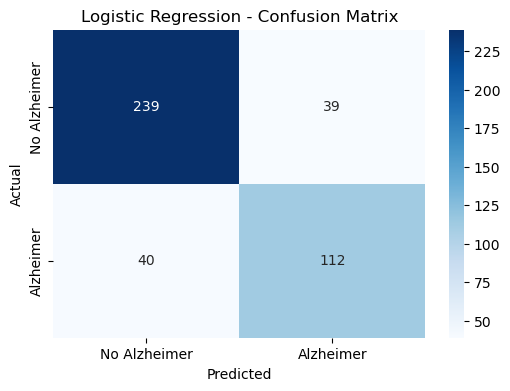

In [36]:
# Confusion Matrix Visualization

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Alzheimer', 'Alzheimer'],
    yticklabels=['No Alzheimer', 'Alzheimer']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')

plt.show()

## Model 2: Decision Tree Classifier

In [37]:
from sklearn.tree import DecisionTreeClassifier

# Creating and training the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### Model Evaluation

In [38]:
# Evaluating Decision Tree

print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall:", round(recall_score(y_test, y_pred_dt), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_dt), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9
Precision: 0.8471
Recall: 0.875
F1 Score: 0.8608

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       278
           1       0.85      0.88      0.86       152

    accuracy                           0.90       430
   macro avg       0.89      0.89      0.89       430
weighted avg       0.90      0.90      0.90       430



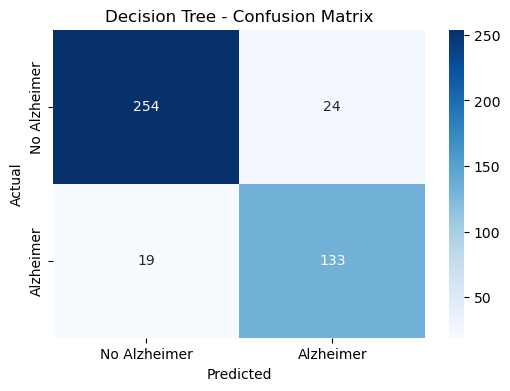

In [39]:
# Confusion Matrix Visualization

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Alzheimer', 'Alzheimer'],
    yticklabels=['No Alzheimer', 'Alzheimer']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')

plt.show()

## Model 3: Random Forest Classifier

In [40]:
from sklearn.ensemble import RandomForestClassifier

# Creating and training the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Model Evaluation

In [41]:
# Evaluating Random Forest

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9372
Precision: 0.9371
Recall: 0.8816
F1 Score: 0.9085

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430



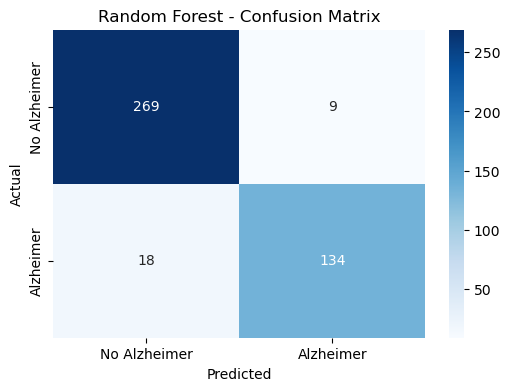

In [42]:
# Confusion Matrix Visualization

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Alzheimer', 'Alzheimer'],
    yticklabels=['No Alzheimer', 'Alzheimer']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')

plt.show()

## Model 4: K-Nearest Neighbors (KNN)

In [43]:
from sklearn.neighbors import KNeighborsClassifier

# Creating and training the model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN model trained successfully.")

KNN model trained successfully.


### Model Evaluation

In [44]:
# Evaluating KNN

print("Accuracy:", round(accuracy_score(y_test, y_pred_knn), 4))
print("Precision:", round(precision_score(y_test, y_pred_knn), 4))
print("Recall:", round(recall_score(y_test, y_pred_knn), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_knn), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.707
Precision: 0.6327
Recall: 0.4079
F1 Score: 0.496

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.87      0.79       278
           1       0.63      0.41      0.50       152

    accuracy                           0.71       430
   macro avg       0.68      0.64      0.64       430
weighted avg       0.69      0.71      0.69       430



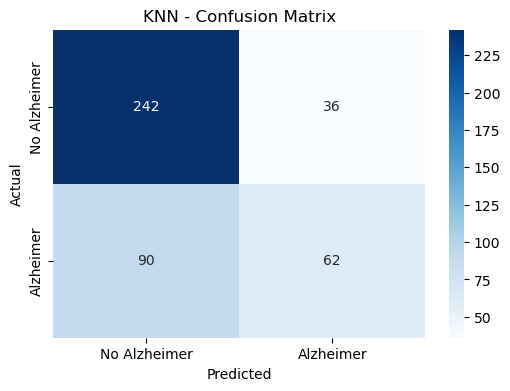

In [45]:
# Confusion Matrix Visualization

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Alzheimer', 'Alzheimer'],
    yticklabels=['No Alzheimer', 'Alzheimer']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN - Confusion Matrix')

plt.show()

## Model Comparison

In [46]:
# Comparing all models

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})

model_comparison = model_comparison.sort_values(
    by='F1 Score',
    ascending=False
)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.9372,0.9371,0.8816,0.9085
1,Decision Tree,0.9000,0.8471,0.8750,0.8608
0,Logistic Regression,0.8163,0.7417,0.7368,0.7393
3,KNN,0.7070,0.6327,0.4079,0.4960


## Random Forest Hyperparameter Tuning

In [47]:
from sklearn.model_selection import GridSearchCV

# Defining parameters for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1 Score: 0.9074


In [48]:
# Creating the optimized Random Forest model

best_rf_model = grid_search.best_estimator_

# Predictions using the optimized model
y_pred_best_rf = best_rf_model.predict(X_test)

# Model evaluation
print("Best Parameters:", grid_search.best_params_)

print("\nAccuracy:", round(accuracy_score(y_test, y_pred_best_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_best_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_best_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_best_rf), 4))

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

Accuracy: 0.9442
Precision: 0.9444
Recall: 0.8947
F1 Score: 0.9189


### Confusion Matrix for Tuned Random Forest

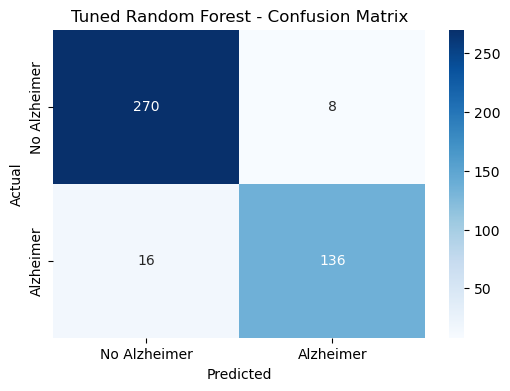

In [49]:
# Confusion Matrix for Tuned Random Forest

cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Alzheimer', 'Alzheimer'],
    yticklabels=['No Alzheimer', 'Alzheimer']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Random Forest - Confusion Matrix')

plt.show()

## Feature Importance Analysis

In [50]:
# Extracting feature importance from the tuned Random Forest model

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,FunctionalAssessment,0.177530
26,ADL,0.165457
22,MMSE,0.118554
24,MemoryComplaints,0.086750
25,BehavioralProblems,0.045558
8,DietQuality,0.032281
7,PhysicalActivity,0.030726
9,SleepQuality,0.030418
21,CholesterolTriglycerides,0.030219
20,CholesterolHDL,0.030206


In [51]:
feature_importance.head(10)

,Feature,Importance
23,FunctionalAssessment,0.177530
26,ADL,0.165457
22,MMSE,0.118554
24,MemoryComplaints,0.086750
25,BehavioralProblems,0.045558
8,DietQuality,0.032281
7,PhysicalActivity,0.030726
9,SleepQuality,0.030418
21,CholesterolTriglycerides,0.030219
20,CholesterolHDL,0.030206


### Top 10 Important Features

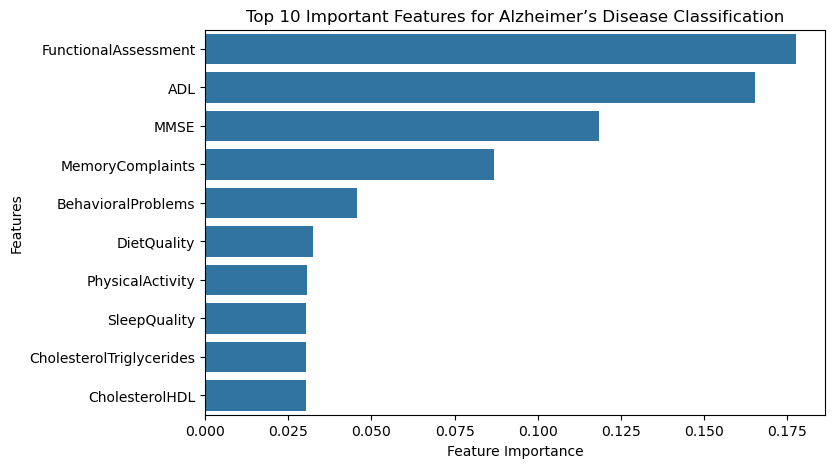

In [52]:
# Visualizing the top 10 important features

top_10_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_10_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features for Alzheimer’s Disease Classification')
plt.xlabel('Feature Importance')
plt.ylabel('Features')

plt.show()

## Final Model Comparison

In [53]:
# Final comparison of the models

final_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_best_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_best_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_best_rf)
    ]
})

final_model_comparison = final_model_comparison.sort_values(
    by='F1 Score',
    ascending=False
)

final_model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
4,Tuned Random Forest,0.9442,0.9444,0.8947,0.9189
2,Random Forest,0.9372,0.9371,0.8816,0.9085
1,Decision Tree,0.9000,0.8471,0.8750,0.8608
0,Logistic Regression,0.8163,0.7417,0.7368,0.7393
3,KNN,0.7070,0.6327,0.4079,0.4960


# Key Findings

- The Tuned Random Forest model performed best among all the evaluated models, achieving an accuracy of 94.42% and an F1-score of 91.89%.
- Hyperparameter tuning improved the Random Forest model performance compared to the original model.
- FunctionalAssessment, ADL, and MMSE were the three most important features contributing to the model's predictions.
- Cognitive and functional assessment variables had higher importance than most lifestyle and medical variables.
- MemoryComplaints and BehavioralProblems were also among the important features associated with the model's classification.
- Among the evaluated models, KNN showed the weakest performance, particularly in identifying Alzheimer's cases.

# Conclusion

This project developed and compared multiple machine learning models for Alzheimer's Disease classification using demographic, lifestyle, medical, clinical, cognitive, and functional factors.

Among the evaluated models, the Tuned Random Forest model achieved the best overall performance and was selected as the final model based on its strong Accuracy, Precision, Recall, and F1-score.

Feature importance analysis showed that FunctionalAssessment, ADL, MMSE, MemoryComplaints, and BehavioralProblems were the most influential features in the model's predictions. Overall, cognitive and functional assessment factors played a more important role in classification than most other variables in this dataset.

The developed model can support the identification of patients who may be at higher risk of Alzheimer's Disease. However, the model should be considered a data-driven decision-support tool and not a substitute for clinical diagnosis.

# PART - 3

# Model Deployment

### Save the final trained model

In [54]:
import joblib

# Saving the final trained model
joblib.dump(best_rf_model, 'alzheimers_rf_model.pkl')

print("Model saved successfully.")

Model saved successfully.


### Save feature names

In [55]:
# Saving the feature names used for model training

feature_names = list(X.columns)

joblib.dump(feature_names, 'feature_names.pkl')

print("Feature names saved successfully.")
print("Number of features:", len(feature_names))

Feature names saved successfully.
Number of features: 32


### Display features

In [56]:
# Display all features used for model training
for i, feature in enumerate(feature_names, start=1):
    print(i, feature)

1 Age
2 Gender
3 Ethnicity
4 EducationLevel
5 BMI
6 Smoking
7 AlcoholConsumption
8 PhysicalActivity
9 DietQuality
10 SleepQuality
11 FamilyHistoryAlzheimers
12 CardiovascularDisease
13 Diabetes
14 Depression
15 HeadInjury
16 Hypertension
17 SystolicBP
18 DiastolicBP
19 CholesterolTotal
20 CholesterolLDL
21 CholesterolHDL
22 CholesterolTriglycerides
23 MMSE
24 FunctionalAssessment
25 MemoryComplaints
26 BehavioralProblems
27 ADL
28 Confusion
29 Disorientation
30 PersonalityChanges
31 DifficultyCompletingTasks
32 Forgetfulness


### Check valid ranges and values

In [57]:
# Checking the range and unique values of all model features

for column in feature_names:
    print(f"\n{column}")
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print("Unique Values:", sorted(df[column].unique())[:20])


Age
Minimum: 60
Maximum: 90
Unique Values: [np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79)]

Gender
Minimum: 0
Maximum: 1
Unique Values: [np.int64(0), np.int64(1)]

Ethnicity
Minimum: 0
Maximum: 3
Unique Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

EducationLevel
Minimum: 0
Maximum: 3
Unique Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

BMI
Minimum: 15.00885118163106
Maximum: 39.99276746402374
Unique Values: [np.float64(15.00885118163106), np.float64(15.012070695981445), np.float64(15.014659194933325), np.float64(15.018239929530528), np.float64(15.031271340942569), np.float64(15.0357235171848), np.float64(15.03674286553689), np.float64(15.070944458989286), np.float64(15.083201432028956), np.float64(15.085792854253915), np.fl

## Final Findings

* The dataset was analyzed using demographic, lifestyle, medical, clinical, cognitive, functional, and symptom-related variables.
* Four classification models were evaluated: Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors (KNN).
* Random Forest performed best among the initial models and was selected for hyperparameter tuning.
* Hyperparameter tuning further improved the Random Forest model.
* The tuned Random Forest achieved **94.42% accuracy, 94.44% precision, 89.47% recall, and 91.89% F1-score** on the test data.
* Feature importance analysis identified **FunctionalAssessment, ADL, MMSE, MemoryComplaints, and BehavioralProblems** as the most influential features in the model's predictions.
* Cognitive and functional assessment variables showed greater importance than most lifestyle and medical variables in this model.
* The tuned Random Forest model was saved and deployed through a Streamlit application for interactive prediction.
* The model predictions represent statistical associations in this dataset and should not be interpreted as medical causation or a clinical diagnosis.

## Final Conclusion

* This project successfully developed an end-to-end machine learning solution for Alzheimer's Disease classification.
* The workflow included data exploration, preprocessing, model development, evaluation, hyperparameter tuning, feature importance analysis, and deployment.
* Among the tested models, the **Tuned Random Forest** provided the strongest overall classification performance and was selected as the final model.
* The model can be used as a **data-driven decision-support demonstration** to identify patterns associated with Alzheimer's Disease classification.
* The Streamlit deployment provides an interactive interface for entering patient information and generating model-based predictions.
* The project demonstrates how machine learning can be applied to healthcare-related datasets for predictive analysis while emphasizing that model output should not replace professional medical diagnosis.
